# Zero-Shot, One-Shot, and Few-Shot Learning on IMDB

This notebook studies how little labeled data can support sentiment classification. It reuses the frozen BERT embeddings from the previous task for repeated KNN experiments and evaluates balanced GPT-2 prompts with zero to three examples per class.

## Learning with different numbers of examples

**Zero-shot learning** performs a task without labeled examples for that task in the prompt or training set. The model must rely on knowledge acquired before the task and on the task description.

**One-shot learning** provides one labeled example for each class. The example establishes how inputs map to labels, but the result can be very sensitive to which example is chosen.

**Few-shot learning** provides a small support set rather than enough examples for ordinary large-sample training. Additional examples can improve class coverage, although improvement is not guaranteed for every random support set.

The word *shot* is sometimes counted per task and sometimes per class. Here it means examples per class, so one-shot binary sentiment uses one negative and one positive example. KNN is not a zero-shot method because it needs labeled neighbors. GPT-2 can be tested without demonstrations, so it also provides the zero-shot baseline.

## Experiment design

The KNN experiment loads the previous task's serialized 128-dimensional BERT Tiny embeddings. A one-nearest-neighbor classifier with cosine distance is fixed before evaluation. For each of 100 seeded episodes, five training examples are drawn per class; the first 1, 3, or 5 form nested support sets. Validation accuracy describes sampling variability. The predeclared first episode is then evaluated once on the untouched test embeddings with accuracy, precision, recall, and F1.

The GPT-2 experiment reconstructs the same model-visible IMDB split used for the saved embeddings. Three short reviews per class are sampled from training data for nested prompts, and six per class are sampled from the held-out test data. GPT-2 is a causal language model rather than an instruction-tuned classifier, so each prompt scores the next-token probabilities of `negative` and `positive`. The small fixed evaluation set demonstrates prompting behavior rather than estimating full-corpus accuracy.

In [1]:
from pathlib import Path
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
import pickle
import shutil
import subprocess
import sys
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BertTokenizerFast,
    logging,
)
from huggingface_hub import logging as hub_logging
from huggingface_hub.utils import disable_progress_bars

SEED = 42
EPISODES = 100
SHOT_COUNTS = (1, 3, 5)
GPT2_MODEL_NAME = "gpt2"
BERT_TOKENIZER_NAME = "google-bert/bert-base-uncased"
MAX_BERT_LENGTH = 96
logging.set_verbosity_error()
logging.disable_progress_bar()
hub_logging.set_verbosity_error()
disable_progress_bars()
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

artifact_path = (
    repository_root
    / "phase-2-deep-learning"
    / "09-transfer-learning"
    / "artifacts"
    / "imdb_bert_tiny_embeddings.pkl"
)
if not artifact_path.exists():
    raise FileNotFoundError(
        "Run the transfer-learning notebook first to create the ignored BERT embedding pickle."
    )
with artifact_path.open("rb") as file:
    stored = pickle.load(file)

required_arrays = {
    "train_embeddings": (6_000, 128),
    "validation_embeddings": (1_500, 128),
    "test_embeddings": (3_000, 128),
    "train_labels": (6_000,),
    "validation_labels": (1_500,),
    "test_labels": (3_000,),
}
for name, expected_shape in required_arrays.items():
    if name not in stored or stored[name].shape != expected_shape:
        raise ValueError(f"{name} does not match the previous task's saved split.")

train_embeddings = normalize(stored["train_embeddings"])
validation_embeddings = normalize(stored["validation_embeddings"])
test_embeddings = normalize(stored["test_embeddings"])
train_labels = stored["train_labels"]
validation_labels = stored["validation_labels"]
test_labels = stored["test_labels"]

print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Loaded embedding shapes: {train_embeddings.shape}, {validation_embeddings.shape}, {test_embeddings.shape}")
print(f"Serialized artifact: {artifact_path.stat().st_size / 1024**2:.2f} MiB")

PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Loaded embedding shapes: (6000, 128), (1500, 128), (3000, 128)
Serialized artifact: 5.21 MiB


## KNN with tiny labeled support sets

L2 normalization makes cosine distance depend on direction rather than embedding magnitude. Each episode draws a new balanced support set from training embeddings only. The nested design keeps the one-shot examples when moving to three and five shots, so the comparison changes by adding labeled examples rather than replacing all of them.

,mean,std,min,max
shots per class,,,,
1,0.5286,0.0320,0.4347,0.6093
3,0.5399,0.0315,0.4540,0.6147
5,0.5429,0.0301,0.4680,0.6167


Repeated KNN validation time: 0.76 seconds


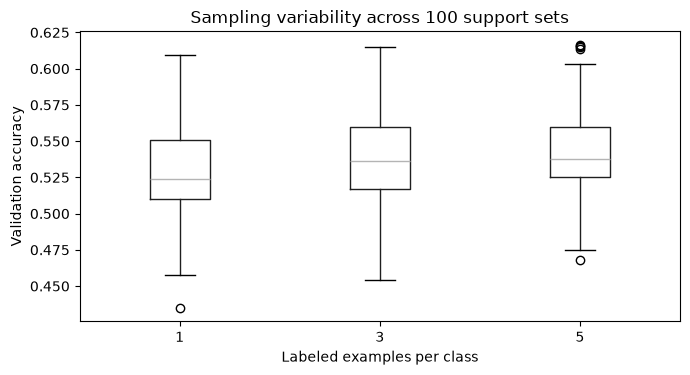

In [2]:
episode_rows = []
primary_support = {}
knn_start = time.perf_counter()

for episode in range(EPISODES):
    rng = np.random.default_rng(SEED + episode)
    class_support = {
        label: rng.choice(
            np.flatnonzero(train_labels == label),
            size=max(SHOT_COUNTS),
            replace=False,
        )
        for label in (0, 1)
    }
    for shots in SHOT_COUNTS:
        support_indices = np.concatenate(
            [class_support[label][:shots] for label in (0, 1)]
        )
        classifier = KNeighborsClassifier(
            n_neighbors=1,
            metric="cosine",
            algorithm="brute",
        )
        classifier.fit(
            train_embeddings[support_indices],
            train_labels[support_indices],
        )
        validation_predictions = classifier.predict(validation_embeddings)
        episode_rows.append(
            {
                "episode": episode + 1,
                "shots per class": shots,
                "validation accuracy": accuracy_score(
                    validation_labels, validation_predictions
                ),
            }
        )
        if episode == 0:
            primary_support[shots] = support_indices

knn_seconds = time.perf_counter() - knn_start
episode_results = pd.DataFrame(episode_rows)
episode_summary = episode_results.groupby("shots per class")[
    "validation accuracy"
].agg(["mean", "std", "min", "max"])
display(episode_summary.style.format("{:.4f}"))
print(f"Repeated KNN validation time: {knn_seconds:.2f} seconds")

fig, axis = plt.subplots(figsize=(7, 4))
episode_results.boxplot(
    column="validation accuracy",
    by="shots per class",
    ax=axis,
    grid=False,
)
axis.set_title("Sampling variability across 100 support sets")
axis.set_xlabel("Labeled examples per class")
axis.set_ylabel("Validation accuracy")
plt.suptitle("")
plt.tight_layout()
plt.show()

assert len(episode_results) == EPISODES * len(SHOT_COUNTS)
assert np.isfinite(episode_summary.to_numpy()).all()

## Predeclared KNN test episode

Only the first seeded support episode is used for held-out reporting. No validation result changes its examples, distance metric, or neighbor count. Accuracy measures all decisions, while precision, recall, and F1 reveal whether a tiny support set favors one sentiment.

,support examples,accuracy,precision,recall,F1
shots per class,,,,,
1,2,0.5363,0.5254,0.7888,0.6307
3,6,0.6023,0.6227,0.5272,0.5710
5,10,0.5897,0.5858,0.6235,0.6041


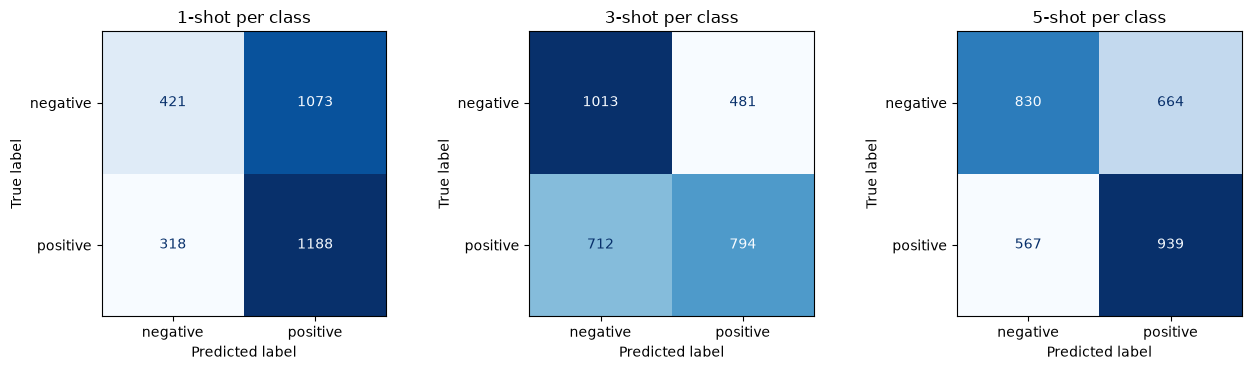

In [3]:
test_rows = []
primary_predictions = {}

for shots in SHOT_COUNTS:
    support_indices = primary_support[shots]
    classifier = KNeighborsClassifier(
        n_neighbors=1,
        metric="cosine",
        algorithm="brute",
    )
    classifier.fit(
        train_embeddings[support_indices],
        train_labels[support_indices],
    )
    predictions = classifier.predict(test_embeddings)
    primary_predictions[shots] = predictions
    test_rows.append(
        {
            "shots per class": shots,
            "support examples": len(support_indices),
            "accuracy": accuracy_score(test_labels, predictions),
            "precision": precision_score(test_labels, predictions),
            "recall": recall_score(test_labels, predictions),
            "F1": f1_score(test_labels, predictions),
        }
    )

knn_test_results = pd.DataFrame(test_rows).set_index("shots per class")
display(knn_test_results.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "F1": "{:.4f}",
}))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for axis, shots in zip(axes, SHOT_COUNTS):
    ConfusionMatrixDisplay.from_predictions(
        test_labels,
        primary_predictions[shots],
        display_labels=["negative", "positive"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(f"{shots}-shot per class")
plt.tight_layout()
plt.show()

assert np.isfinite(knn_test_results.to_numpy()).all()

## Balanced prompting with GPT-2

The preprocessing and BERT WordPiece truncation from the previous task are reapplied to reconstruct its exact split. Prompt demonstrations come only from its training subset, and target reviews come only from its test subset. Short reviews keep every complete prompt within GPT-2's context window. The examples are nested: two-shot retains the one-shot examples, and three-shot retains the first two.

Because plain GPT-2 was trained for next-token prediction rather than instruction following, the classifier compares the logits for the single tokens ` negative` and ` positive` after `Sentiment:`. This constrained scoring avoids relying on unconstrained generated text.

In [4]:
from sklearn.model_selection import train_test_split

phase_1 = repository_root / "phase-1-machine-learning-nlp"
preprocessing_part = phase_1 / "02-preprocessing-tokenization"
sys.path.insert(0, str(preprocessing_part / "src"))
from preprocessor import preprocess_text

imdb_path = preprocessing_part / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

split_start = time.perf_counter()
imdb = pd.read_csv(imdb_path).dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
imdb["cleaned_text"] = imdb["review"].map(
    lambda review: preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
)
bert_tokenizer = BertTokenizerFast.from_pretrained(BERT_TOKENIZER_NAME)
bert_tokenizer.model_max_length = 100_000
model_keys = []
texts = imdb["cleaned_text"].tolist()
for start in range(0, len(texts), 2_000):
    encoded = bert_tokenizer(
        texts[start:start + 2_000],
        add_special_tokens=True,
        truncation=True,
        padding="max_length",
        max_length=MAX_BERT_LENGTH,
        return_attention_mask=False,
        return_token_type_ids=False,
        return_tensors="np",
    )["input_ids"]
    model_keys.extend(row.tobytes() for row in encoded)
imdb["model_key"] = model_keys
if imdb.groupby("model_key")["label"].nunique().gt(1).any():
    raise ValueError("Model-visible duplicates have conflicting labels.")
imdb = imdb.drop_duplicates(subset="model_key")
development_full, test_full = train_test_split(
    imdb, test_size=0.20, random_state=SEED, stratify=imdb["label"]
)
train_full, validation_full = train_test_split(
    development_full,
    test_size=0.25,
    random_state=SEED,
    stratify=development_full["label"],
)

def stratified_subset(frame, size, seed):
    selected, _ = train_test_split(
        frame, train_size=size, random_state=seed, stratify=frame["label"]
    )
    return selected.reset_index(drop=True)

train = stratified_subset(train_full, 6_000, SEED)
test = stratified_subset(test_full, 3_000, SEED + 2)
assert set(train["model_key"]).isdisjoint(test["model_key"])
assert np.array_equal(test["label"].to_numpy(), test_labels)

gpt2_tokenizer = AutoTokenizer.from_pretrained(GPT2_MODEL_NAME)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

def token_lengths(texts):
    return [
        len(token_ids)
        for token_ids in gpt2_tokenizer(
            texts, add_special_tokens=False
        )["input_ids"]
    ]

train["gpt2 tokens"] = token_lengths(train["cleaned_text"].tolist())
test["gpt2 tokens"] = token_lengths(test["cleaned_text"].tolist())

def balanced_sample(frame, count, seed, minimum_tokens, maximum_tokens):
    rng = np.random.default_rng(seed)
    selected = []
    for label in (0, 1):
        candidates = frame[
            (frame["label"] == label)
            & frame["gpt2 tokens"].between(minimum_tokens, maximum_tokens)
        ].index.to_numpy()
        selected.extend(rng.choice(candidates, count, replace=False))
    return frame.loc[selected].sort_values("label").reset_index(drop=True)

demonstrations = balanced_sample(train, 3, SEED, 15, 45)
prompt_test = balanced_sample(test, 6, SEED + 100, 20, 70)
split_seconds = time.perf_counter() - split_start

model_load_start = time.perf_counter()
gpt2 = AutoModelForCausalLM.from_pretrained(GPT2_MODEL_NAME).to(device)
gpt2.eval()
model_load_seconds = time.perf_counter() - model_load_start

sample_summary = pd.DataFrame(
    {
        "reviews": [len(demonstrations), len(prompt_test)],
        "negative": [
            int((demonstrations["label"] == 0).sum()),
            int((prompt_test["label"] == 0).sum()),
        ],
        "positive": [
            int((demonstrations["label"] == 1).sum()),
            int((prompt_test["label"] == 1).sum()),
        ],
        "mean GPT-2 tokens": [
            demonstrations["gpt2 tokens"].mean(),
            prompt_test["gpt2 tokens"].mean(),
        ],
    },
    index=["training demonstrations", "held-out prompt test"],
)
display(sample_summary.style.format({"mean GPT-2 tokens": "{:.2f}"}))
print(f"Split reconstruction and sampling time: {split_seconds:.2f} seconds")
print(f"GPT-2 parameters: {gpt2.num_parameters():,}")
print(f"GPT-2 load time: {model_load_seconds:.2f} seconds")

,reviews,negative,positive,mean GPT-2 tokens
training demonstrations,6,3,3,30.83
held-out prompt test,12,6,6,53.50


Split reconstruction and sampling time: 31.55 seconds
GPT-2 parameters: 124,439,808
GPT-2 load time: 0.94 seconds


,demonstrations,accuracy,macro F1,mean confidence,maximum prompt tokens
shots per class,,,,,
0,0,0.5833,0.4958,0.6482,85
1,2,0.4167,0.2941,0.6076,187
2,4,0.7500,0.7333,0.5391,273
3,6,0.7500,0.7333,0.5487,324


,true label,prediction,positive probability,review
36,negative,negative,0.4539,this is pretty funny saturday the th a great work i laughed every minute of the movie this
37,negative,negative,0.4490,olivia dabo in a wet tshirt is the only thing this movie has going for it other than that
38,negative,negative,0.4329,so many films are now in a genre described as comedythriller as was this one a fine cast i
39,negative,negative,0.4495,this hokey movie left me groaning after just about any exchange of dialogue or plot compli
40,negative,negative,0.4772,yes you guessed it another movie where identical twins switch places i think now that the
41,negative,negative,0.4454,i am almost tempted to demand my money back from the video store this movie plumbs the dep
42,positive,negative,0.4390,the biggest heroes is one of the greatest movies ever a good story great actors and a bril
43,positive,negative,0.3509,it is an almost ideal romantic anime must see for all ages but the english dubbed version
44,positive,negative,0.4826,undoubtedly the funniest movie i have ever seen its definitely worth the fourteen minutes
45,positive,positive,0.5084,this movie really rocks jeff wincott is terrific in the film his fighting incredible he is


Prompt scoring time: 17.52 seconds


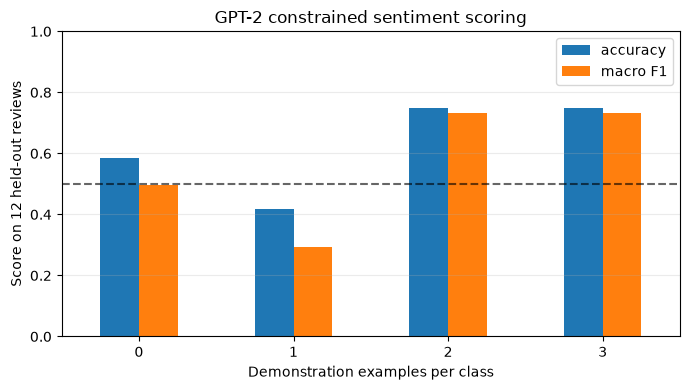

In [5]:
label_text = {0: "negative", 1: "positive"}
label_token_ids = [
    gpt2_tokenizer.encode(
        f" {label_text[label]}", add_special_tokens=False
    )
    for label in (0, 1)
]
if any(len(token_ids) != 1 for token_ids in label_token_ids):
    raise ValueError("Each candidate label must be one GPT-2 token.")
label_token_ids = [token_ids[0] for token_ids in label_token_ids]

def build_prompt(target_text, shots_per_class):
    lines = ["Classify each movie review as negative or positive."]
    for shot_index in range(shots_per_class):
        for label in (0, 1):
            example = demonstrations[
                demonstrations["label"] == label
            ].iloc[shot_index]
            lines.extend(
                [
                    "",
                    f"Review: {example['cleaned_text']}",
                    f"Sentiment: {label_text[label]}",
                ]
            )
    lines.extend(["", f"Review: {target_text}", "Sentiment:"])
    return "\n".join(lines)

def score_prompts(prompts):
    batch = gpt2_tokenizer(
        prompts,
        padding=True,
        return_tensors="pt",
    ).to(device)
    prompt_lengths = batch["attention_mask"].sum(dim=1)
    if int(prompt_lengths.max()) >= gpt2.config.n_positions:
        raise ValueError("A prompt exceeds GPT-2's context window.")
    with torch.no_grad():
        logits = gpt2(**batch).logits
    final_positions = prompt_lengths - 1
    candidate_logits = logits[
        torch.arange(len(prompts), device=device), final_positions
    ][:, label_token_ids]
    probabilities = torch.softmax(candidate_logits, dim=1).cpu().numpy()
    return probabilities, prompt_lengths.cpu().numpy()

prompt_rows = []
case_rows = []
prompt_start = time.perf_counter()
for shots in (0, 1, 2, 3):
    prompts = [
        build_prompt(text, shots)
        for text in prompt_test["cleaned_text"]
    ]
    probabilities, prompt_lengths = score_prompts(prompts)
    predictions = probabilities.argmax(axis=1)
    prompt_rows.append(
        {
            "shots per class": shots,
            "demonstrations": shots * 2,
            "accuracy": accuracy_score(prompt_test["label"], predictions),
            "macro F1": f1_score(
                prompt_test["label"], predictions, average="macro"
            ),
            "mean confidence": probabilities.max(axis=1).mean(),
            "maximum prompt tokens": prompt_lengths.max(),
        }
    )
    for row_index, row in prompt_test.iterrows():
        case_rows.append(
            {
                "shots per class": shots,
                "true label": label_text[row["label"]],
                "prediction": label_text[predictions[row_index]],
                "positive probability": probabilities[row_index, 1],
                "review": row["cleaned_text"][:90],
            }
        )

prompt_seconds = time.perf_counter() - prompt_start
prompt_results = pd.DataFrame(prompt_rows).set_index("shots per class")
prompt_cases = pd.DataFrame(case_rows)
display(prompt_results.style.format({
    "accuracy": "{:.4f}",
    "macro F1": "{:.4f}",
    "mean confidence": "{:.4f}",
}))
display(
    prompt_cases[prompt_cases["shots per class"] == 3]
    .drop(columns="shots per class")
    .style.format({"positive probability": "{:.4f}"})
)
print(f"Prompt scoring time: {prompt_seconds:.2f} seconds")

fig, axis = plt.subplots(figsize=(7, 4))
prompt_results[["accuracy", "macro F1"]].plot(
    kind="bar",
    ylim=(0, 1),
    rot=0,
    ax=axis,
)
axis.axhline(0.5, color="black", linestyle="--", alpha=0.6)
axis.set_title("GPT-2 constrained sentiment scoring")
axis.set_xlabel("Demonstration examples per class")
axis.set_ylabel("Score on 12 held-out reviews")
axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

assert np.isfinite(prompt_results.to_numpy()).all()
assert len(prompt_cases) == 48

In [6]:
one_shot_mean = episode_summary.loc[1, "mean"]
three_shot_mean = episode_summary.loc[3, "mean"]
five_shot_mean = episode_summary.loc[5, "mean"]
best_prompt_shots = int(prompt_results["accuracy"].idxmax())
best_prompt_accuracy = prompt_results.loc[best_prompt_shots, "accuracy"]
display(Markdown(
    f'''## Observations

Across **{EPISODES}** KNN support episodes, mean validation accuracy rose from **{one_shot_mean:.4f}** with one example per class to **{three_shot_mean:.4f}** with three and **{five_shot_mean:.4f}** with five. The distributions still overlap substantially, showing that support-example quality matters as much as the count at this scale.

In the predeclared test episode, one-, three-, and five-shot accuracy were **{knn_test_results.loc[1, 'accuracy']:.4f}**, **{knn_test_results.loc[3, 'accuracy']:.4f}**, and **{knn_test_results.loc[5, 'accuracy']:.4f}**. Five shots did not beat three in this particular episode, even though the repeated validation mean increased. With so few labels, adding examples does not guarantee a monotonic result for every draw.

GPT-2's best result on the fixed 12-review prompt set used **{best_prompt_shots}** demonstration examples per class and reached accuracy **{best_prompt_accuracy:.4f}**. Zero-, one-, two-, and three-shot accuracies were **{prompt_results.loc[0, 'accuracy']:.4f}**, **{prompt_results.loc[1, 'accuracy']:.4f}**, **{prompt_results.loc[2, 'accuracy']:.4f}**, and **{prompt_results.loc[3, 'accuracy']:.4f}**. More demonstrations changed the model's label preference but did not improve accuracy monotonically. The result is sensitive to prompt wording, example choice, example order, and the use of a base causal model that was not instruction-tuned.

The detected system GPU was **{gpu_name}**, but PyTorch exposed CUDA as **{torch.cuda.is_available()}**. The experiment therefore used **{device}** with **{torch.get_num_threads()}** CPU threads. Repeated KNN validation took **{knn_seconds:.2f} seconds**, split reconstruction took **{split_seconds:.2f} seconds**, GPT-2 loading took **{model_load_seconds:.2f} seconds**, and prompt scoring took **{prompt_seconds:.2f} seconds**. The pretrained model stayed in the external Hugging Face cache, and no new model artifact was written to the repository.'''
))

## Observations

Across **100** KNN support episodes, mean validation accuracy rose from **0.5286** with one example per class to **0.5399** with three and **0.5429** with five. The distributions still overlap substantially, showing that support-example quality matters as much as the count at this scale.

In the predeclared test episode, one-, three-, and five-shot accuracy were **0.5363**, **0.6023**, and **0.5897**. Five shots did not beat three in this particular episode, even though the repeated validation mean increased. With so few labels, adding examples does not guarantee a monotonic result for every draw.

GPT-2's best result on the fixed 12-review prompt set used **2** demonstration examples per class and reached accuracy **0.7500**. Zero-, one-, two-, and three-shot accuracies were **0.5833**, **0.4167**, **0.7500**, and **0.7500**. More demonstrations changed the model's label preference but did not improve accuracy monotonically. The result is sensitive to prompt wording, example choice, example order, and the use of a base causal model that was not instruction-tuned.

The detected system GPU was **NVIDIA GeForce RTX 3050 Ti Laptop GPU**, but PyTorch exposed CUDA as **False**. The experiment therefore used **cpu** with **8** CPU threads. Repeated KNN validation took **0.76 seconds**, split reconstruction took **31.55 seconds**, GPT-2 loading took **0.94 seconds**, and prompt scoring took **17.52 seconds**. The pretrained model stayed in the external Hugging Face cache, and no new model artifact was written to the repository.